# Smart Industrial Maintenance System — Repo Pipeline
## FSE 570 Capstone | Arizona State University

This notebook runs the full **C-MAPSS turbofan engine** maintenance pipeline using **the repository's
modular source code** (`src/`, `config.py`). It imports all models, preprocessing,
explainability, optimization, and evaluation modules rather than re-implementing them inline.

> **Prerequisites:** Install the project in editable mode first:
> ```bash
> pip install -e .
> ```
> This makes `config`, `src.*`, etc. importable from anywhere.

| Module | Purpose |
|---|---|
| `config` | Central hyperparameters, paths, device config |
| `src.data.download` | C-MAPSS dataset download & loading (all 4 subsets) |
| `src.data.preprocess` | Normalization, splitting, synthetic augmentation |
| `src.data.synthetic_cmapss` | Synthetic degradation trajectory generation |
| `src.models.autoencoder` | LSTM Autoencoder (anomaly detection) |
| `src.models.lstm_predictor` | LSTM + Attention (failure classification) |
| `src.models.xgboost_rul` | XGBoost (RUL regression) |
| `src.models.bayesian_survival` | Weibull AFT (survival analysis) |
| `src.optimization.milp_scheduler` | MILP maintenance scheduling |
| `src.evaluation.simulation` | Monte Carlo policy comparison |
| `src.explainability.shap_analysis` | SHAP feature attribution |
| `src.explainability.attention_viz` | Temporal attention visualization |

---
## 1. Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import torch
%matplotlib inline
import matplotlib.pyplot as plt

# --- Project modules (available via `pip install -e .`) ---
import config
from src.data.download import download_cmapss, load_cmapss_train, load_cmapss_all_subsets
from src.data.preprocess import DataPreprocessor
from src.data.synthetic_cmapss import SyntheticCMAPSSGenerator
from src.models.autoencoder import LSTMAutoencoder, AutoencoderTrainer
from src.models.lstm_predictor import LSTMPredictor, PredictorTrainer
from src.models.xgboost_rul import XGBoostRUL
from src.models.bayesian_survival import BayesianSurvival
from src.optimization.milp_scheduler import MaintenanceScheduler
from src.evaluation.simulation import MaintenanceSimulator
from src.explainability.shap_analysis import SHAPExplainer
from src.explainability.attention_viz import AttentionVisualizer

# Reproducibility
torch.manual_seed(config.RANDOM_SEED)
np.random.seed(config.RANDOM_SEED)

config.print_system_info()
print(f"Random Seed: {config.RANDOM_SEED}")

d:\Capstone Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[CONFIG] Using device: cuda
[CONFIG] System RAM available: 14.9 GB
[CONFIG] GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
[CONFIG] VRAM: 4.0 GB
[CONFIG] Auto batch size: 32 (AE) / 32 (Pred)
[CONFIG] Auto hidden dim: 64 (AE) / 64 (Pred)
[CONFIG] DataLoader workers: 4
Random Seed: 42


---
## 2. Download & Load C-MAPSS Data

In [2]:
# Download C-MAPSS if not present
download_cmapss()

# Load all 4 subsets (FD001-FD004) with globally unique unit IDs
df_raw = load_cmapss_all_subsets()

print(f"\nLoaded {df_raw['unit_id'].nunique()} units, {len(df_raw)} rows")
print(f"Subsets: {config.CMAPSS_SUBSETS}")
print(f"Columns: {list(df_raw.columns[:10])}...")

[DOWNLOAD] Dataset already present (11 files). Skipping download.
  - RUL_FD002.txt (0.00 MB)
  - RUL_FD004.txt (0.00 MB)
  - readme.txt (0.00 MB)
  - test_FD001.txt (2.23 MB)
  - test_FD002.txt (5.73 MB)
  - test_FD003.txt (2.83 MB)
  - test_FD004.txt (6.96 MB)
  - train_FD001.txt (3.52 MB)
  - train_FD002.txt (9.08 MB)
  - train_FD003.txt (4.21 MB)
  - train_FD004.txt (10.35 MB)
[DOWNLOAD] Loading training data from: D:\Capstone Project\data\raw\train_FD001.txt
[DOWNLOAD] Loaded 20631 rows, 100 units
[DOWNLOAD] Cycle range: 1 - 362
[DOWNLOAD] RUL range: 0 - 125
[DOWNLOAD] FD001: 100 units, 20631 rows
[DOWNLOAD] Loading training data from: D:\Capstone Project\data\raw\train_FD002.txt
[DOWNLOAD] Loaded 53759 rows, 260 units
[DOWNLOAD] Cycle range: 1 - 378
[DOWNLOAD] RUL range: 0 - 125
[DOWNLOAD] FD002: 260 units, 53759 rows
[DOWNLOAD] Loading training data from: D:\Capstone Project\data\raw\train_FD003.txt
[DOWNLOAD] Loaded 24720 rows, 100 units
[DOWNLOAD] Cycle range: 1 - 525
[DOWNLOA

---
## 2b. Synthetic Maintenance Data

Generates maintenance logs and operational context used by the dashboard's
Maintenance History and Operational Context pages.
Equivalent to Step 2 in `train_all.py`.

In [3]:
from src.data.synthetic_generator import SyntheticDataGenerator

generator = SyntheticDataGenerator()
logs, context, schedule_syn = generator.generate_all(df_raw)
print(f"Synthetic logs: {len(logs)} records, context: {len(context)} machines")
print(f"Saved to {config.SYNTHETIC_DATA_DIR}")


Generating Synthetic Industrial Data
[SYNTHETIC] Generated 3568 maintenance logs for 709 units
  Planned: 2398 | Unplanned: 1170
  Total cost: $29,652,781
[SYNTHETIC] Generated operational context for 709 units

[SYNTHETIC] All data saved to D:\Capstone Project\data\synthetic
Synthetic logs: 3568 records, context: 709 machines
Saved to D:\Capstone Project\data\synthetic


---
## 3. Preprocessing & Synthetic Augmentation

The `DataPreprocessor` handles the full pipeline:
1. Drop constant / near-constant sensors (per `config.SENSORS_TO_DROP`)
2. Handle missing values (forward-fill per unit)
3. Temporal train/val/test split by unit ID (34 / 33 / 33 %)
4. Synthetic augmentation — injects ~30 % synthetic C-MAPSS trajectories into **training only**
5. Min-max normalization (fit on augmented training set, transform val/test)
6. Sliding window sequences (30-cycle windows) for LSTM input

In [4]:
# Drop 'subset' column (not a feature)
df_for_preprocess = df_raw.drop(columns=["subset"], errors="ignore")

preprocessor = DataPreprocessor()
data = preprocessor.fit_transform(df_for_preprocess, augment=config.SYNTHETIC_AUGMENT)
preprocessor.save()

# Save preprocessed sequences — dashboard and run_pipeline.py load these
for split_name, split_data in data.items():
    np.savez_compressed(
        os.path.join(config.PROCESSED_DATA_DIR, f"{split_name}_data.npz"),
        X=split_data["X"],
        y_rul=split_data["y_rul"],
        y_binary=split_data["y_binary"],
        unit_ids=split_data["unit_ids"],
    )
print("Preprocessed splits saved to", config.PROCESSED_DATA_DIR)

# Unpack splits
X_train = data["train"]["X"]
y_train_rul = data["train"]["y_rul"]
y_train_binary = data["train"]["y_binary"]
X_val = data["val"]["X"]
y_val_rul = data["val"]["y_rul"]
y_val_binary = data["val"]["y_binary"]
X_test = data["test"]["X"]
y_test_rul = data["test"]["y_rul"]
y_test_binary = data["test"]["y_binary"]
unit_ids_test = data["test"]["unit_ids"]  # needed for per-unit scheduling

n_features = X_train.shape[2]

print(f"\n{'Split':<8} {'Sequences':>10} {'Failure%':>10} {'RUL range':>15}")
print("-" * 45)
for name, d in data.items():
    print(f"{name:<8} {d['X'].shape[0]:>10} {d['y_binary'].mean():>10.2%} "
          f"[{d['y_rul'].min():.0f}, {d['y_rul'].max():.0f}]")


Running Full Preprocessing Pipeline
[PREPROCESS] Dropped 8 constant columns: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'op_setting_3']
[PREPROCESS] No missing values detected
[PREPROCESS] Split: train=496 units (111227 rows), val=106 units (24961 rows), test=107 units (24171 rows)

[PREPROCESS] Augmenting training data with synthetic units (target ratio: 30%)...
[SYNTHETIC CMAPSS] Fitted on 496 real units
[SYNTHETIC CMAPSS] Sensors: 14, Lifetime: 224 ± 64 cycles
[SYNTHETIC CMAPSS] Generated 212 synthetic units (48108 rows, degradation models: exponential, linear, polynomial)
[SYNTHETIC CMAPSS] Augmentation: 111227 real + 48108 synthetic = 159335 total (synthetic ratio: 30.2%, target: 30%)
[PREPROCESS] Training set: 111227 real + 48108 synthetic = 159335 total
[PREPROCESS] Fitted scaler on 16 features
[PREPROCESS] Created 138803 sequences of shape (30, 16)
[PREPROCESS] train: X=(138803, 30, 16), y_rul range=[0, 125], failure_rate=15.81%
[PR

---
## 4. Model 1: LSTM Autoencoder (Anomaly Detection)

Trained on **healthy data only** (RUL > failure horizon). Reconstruction error serves
as the anomaly score — degrading bearings produce patterns the autoencoder cannot
reconstruct well.

In [5]:
autoencoder = LSTMAutoencoder(input_dim=n_features, seq_len=config.SEQUENCE_LENGTH)
ae_trainer = AutoencoderTrainer(autoencoder)

# Filter healthy samples for training (RUL > 50 % of MAX_RUL)
healthy_threshold = config.MAX_RUL * 0.5
healthy_mask = y_train_rul > healthy_threshold
X_healthy = X_train[healthy_mask]
X_val_ae = X_val[y_val_rul > healthy_threshold] if len(X_val) > 0 else None

if len(X_healthy) < 10:
    print(f"Warning: Only {len(X_healthy)} healthy samples. Using all training data.")
    X_healthy = X_train
    X_val_ae = X_val

print(f"Training autoencoder on {len(X_healthy)} healthy samples "
      f"(out of {len(X_train)} total, threshold RUL>{healthy_threshold:.0f})")

ae_trainer.train(X_healthy, X_val_ae if X_val_ae is not None and len(X_val_ae) > 0 else None)
ae_trainer.save_model(os.path.join(config.MODELS_DIR, "autoencoder.pt"))

Training autoencoder on 94199 healthy samples (out of 138803 total, threshold RUL>62)

[AUTOENCODER] Training on cuda (94199 samples, 50 epochs, batch_size=32)


[AE] Epochs: 100%|██████████| 50/50 [23:37<00:00, 28.36s/epoch, train_loss=0.007589, val_loss=0.009001]


[AUTOENCODER] Restored best model (val_loss=0.009001)
[AUTOENCODER] Threshold set: 0.029200 (mean=0.009001, std=0.006733)
[AUTOENCODER] Threshold derived from: val
[AUTOENCODER] Model saved to D:\Capstone Project\models\saved\autoencoder.pt


[AUTOENCODER] Threshold set: 0.029200 (mean=0.009001, std=0.006733)


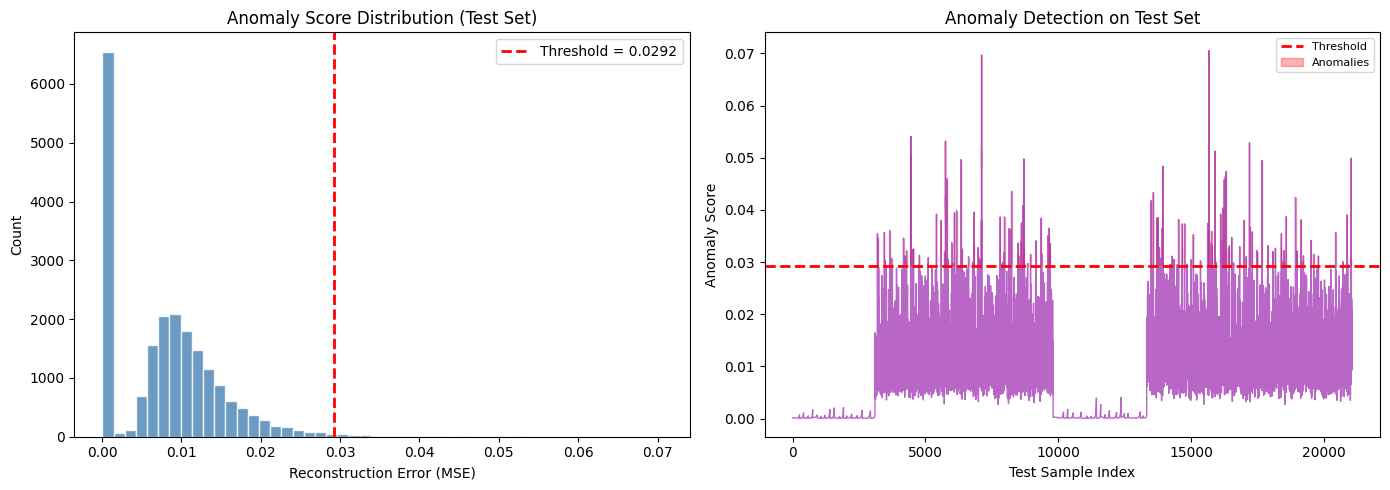

Anomalies detected: 205/21068 (1.0%)


In [6]:
# Set threshold from VALIDATION data (not training) — avoids inflated threshold
X_val_healthy = X_val[y_val_rul > config.MAX_RUL * 0.5]
if len(X_val_healthy) > 0:
    val_scores = autoencoder.compute_anomaly_score(
        torch.tensor(X_val_healthy, dtype=torch.float32))
    autoencoder.set_threshold(val_scores)
else:
    healthy_scores = autoencoder.compute_anomaly_score(
        torch.tensor(X_healthy, dtype=torch.float32))
    autoencoder.set_threshold(healthy_scores)
    print("[WARN] No val healthy samples - threshold set from training data")

# Anomaly scores on test set
anomaly_scores = autoencoder.compute_anomaly_score(
    torch.tensor(X_test, dtype=torch.float32))
_, anomalies = autoencoder.detect_anomalies(
    torch.tensor(X_test, dtype=torch.float32))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(anomaly_scores, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(autoencoder.threshold, color='red', linestyle='--', linewidth=2,
                label=f'Threshold = {autoencoder.threshold:.4f}')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Count')
axes[0].set_title('Anomaly Score Distribution (Test Set)')
axes[0].legend()
axes[1].plot(anomaly_scores, color='#9C27B0', alpha=0.7, linewidth=1)
axes[1].axhline(autoencoder.threshold, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[1].fill_between(range(len(anomaly_scores)), anomaly_scores, autoencoder.threshold,
                     where=anomaly_scores > autoencoder.threshold,
                     alpha=0.3, color='red', label='Anomalies')
axes[1].set_xlabel('Test Sample Index')
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('Anomaly Detection on Test Set')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f'Anomalies detected: {anomalies.sum()}/{len(anomalies)} ({anomalies.mean():.1%})')


---
## 5. Model 2: LSTM Failure Predictor with Attention

Binary classifier predicting P(failure within h cycles). Uses an attention mechanism
to weight which time steps are most informative for the prediction.

In [7]:
predictor = LSTMPredictor(input_dim=n_features)
pred_trainer = PredictorTrainer(predictor)
pred_trainer.train(X_train, y_train_binary, X_val, y_val_binary)
pred_trainer.save_model(os.path.join(config.MODELS_DIR, "lstm_predictor.pt"))


[PREDICTOR] Training on cuda (138803 samples, pos_rate=15.81%, batch_size=32)
[PREDICTOR] Positive weight: 5.32


[PRED] Epochs:   0%|          | 0/50 [00:00<?, ?epoch/s]

[PRED] Epochs: 100%|██████████| 50/50 [26:11<00:00, 31.42s/epoch, train_loss=0.2742, F1=0.8291, AUC=0.9790]

[PREDICTOR] Restored best model (AUC=0.9875)
[PREDICTOR] Model saved to D:\Capstone Project\models\saved\lstm_predictor.pt


Classification Report (Test Set):
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.97     17751
     Failure       0.80      0.93      0.86      3317

    accuracy                           0.95     21068
   macro avg       0.89      0.95      0.92     21068
weighted avg       0.96      0.95      0.95     21068



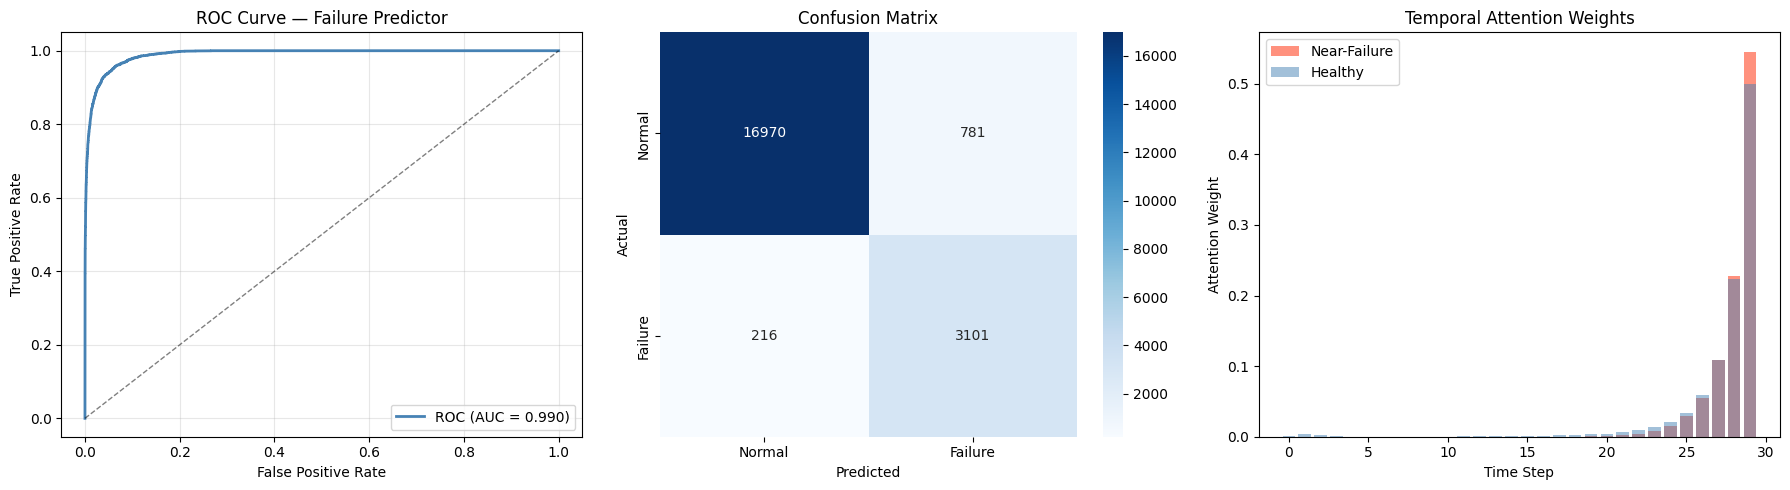

F1 Score: 0.8615
ROC AUC:  0.9898


In [8]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, f1_score)
import seaborn as sns

# Evaluate on test set
y_proba, attn_weights_test = predictor.predict_proba(torch.tensor(X_test, dtype=torch.float32))
y_pred = (y_proba >= 0.5).astype(int)

print("Classification Report (Test Set):")
print(classification_report(y_test_binary.astype(int), y_pred,
                            target_names=["Normal", "Failure"], zero_division=0))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC Curve
axes[0].plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Failure Predictor")
axes[0].legend(loc="lower right"); axes[0].grid(True, alpha=0.3)

# 2. Confusion matrix
cm = confusion_matrix(y_test_binary.astype(int), y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Normal", "Failure"], yticklabels=["Normal", "Failure"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix")

# 3. Attention weights: failure vs normal comparison
avg_attn_fail = attn_weights_test[y_test_binary == 1].mean(axis=0) if y_test_binary.sum() > 0 else attn_weights_test.mean(axis=0)
avg_attn_ok = attn_weights_test[y_test_binary == 0].mean(axis=0) if (y_test_binary == 0).sum() > 0 else attn_weights_test.mean(axis=0)
axes[2].bar(range(len(avg_attn_fail)), avg_attn_fail, alpha=0.7, label="Near-Failure", color="tomato")
axes[2].bar(range(len(avg_attn_ok)), avg_attn_ok, alpha=0.5, label="Healthy", color="steelblue")
axes[2].set_xlabel("Time Step"); axes[2].set_ylabel("Attention Weight")
axes[2].set_title("Temporal Attention Weights"); axes[2].legend()

plt.tight_layout()
plt.show()

f1_test = f1_score(y_test_binary.astype(int), y_pred, zero_division=0)
print(f"F1 Score: {f1_test:.4f}")
print(f"ROC AUC:  {roc_auc:.4f}")

---
## 6. Model 3: XGBoost RUL Estimation

Gradient-boosted regression on engineered tabular C-MAPSS features for remaining useful life prediction.
Uses the same unit-based split seed as the sequential preprocessor.

In [9]:
from src.data.feature_engineering import FeatureEngineer

# Feature engineering on raw data for XGBoost
df_for_fe = df_raw.drop(columns=["subset"], errors="ignore").copy()
fe = FeatureEngineer()
df_engineered = fe.engineer_features(df_for_fe)

# Unit-based temporal split (same seed as preprocessor)
exclude_cols = ["unit_id", "cycle", "RUL"]
feature_cols = [c for c in df_engineered.columns if c not in exclude_cols]

unit_ids = df_engineered["unit_id"].unique()
np.random.seed(config.RANDOM_SEED)
np.random.shuffle(unit_ids)
n = len(unit_ids)
n_train = int(n * config.TRAIN_RATIO)
n_val = int(n * config.VAL_RATIO)
train_units = unit_ids[:n_train]
val_units = unit_ids[n_train:n_train + n_val]
test_units = unit_ids[n_train + n_val:]

X_train_xgb = df_engineered[df_engineered["unit_id"].isin(train_units)][feature_cols]
y_train_xgb = df_engineered[df_engineered["unit_id"].isin(train_units)]["RUL"]
X_val_xgb = df_engineered[df_engineered["unit_id"].isin(val_units)][feature_cols]
y_val_xgb = df_engineered[df_engineered["unit_id"].isin(val_units)]["RUL"]
X_test_xgb = df_engineered[df_engineered["unit_id"].isin(test_units)][feature_cols]
y_test_xgb = df_engineered[df_engineered["unit_id"].isin(test_units)]["RUL"]

xgb_model = XGBoostRUL()
xgb_model.train(X_train_xgb, y_train_xgb.values, X_val_xgb, y_val_xgb.values,
                feature_names=feature_cols)

print("\nTest Set Evaluation:")
xgb_model.evaluate(X_test_xgb, y_test_xgb.values)

xgb_model.save()
print("XGBoost model saved to", config.MODELS_DIR)


Running Feature Engineering Pipeline


D:\Capstone Project\src\data\feature_engineering.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = series
D:\Capstone Project\src\data\feature_engineering.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = series
D:\Capstone Project\src\data\feature_engineering.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-f

[FEATURES] Added 168 rolling features (3 windows × 4 stats × 14 sensors)


D:\Capstone Project\src\data\feature_engineering.py:115: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = series
D:\Capstone Project\src\data\feature_engineering.py:115: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = series
D:\Capstone Project\src\data\feature_engineering.py:115: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a d

[FEATURES] Added 14 trend features


D:\Capstone Project\src\data\feature_engineering.py:141: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["operating_regime"] = self.regime_model.fit_predict(df[op_cols])
D:\Capstone Project\src\data\feature_engineering.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = np.nan
D:\Capstone Project\src\data\feature_engineering.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

[FEATURES] Clustered 2 settings into 3 regimes:
  Regime 0: 34354 observations (21.4%)
  Regime 1: 79953 observations (49.9%)
  Regime 2: 46052 observations (28.7%)
[FEATURES] Added 42 lag features (3 lags × 14 sensors)
[FEATURES] Added 20 interaction features from top-5 sensors

[FEATURES] Total features: 27 -> 272 (+245 engineered)


D:\Capstone Project\src\data\feature_engineering.py:195: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{s1}_x_{s2}"] = df[s1] * df[s2]
D:\Capstone Project\src\data\feature_engineering.py:196: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{s1}_div_{s2}"] = df[s1] / (df[s2] + 1e-8)
D:\Capstone Project\src\data\feature_engineering.py:195: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once us

[XGBOOST] Training with 269 features, 111227 samples
[0]	validation_0-rmse:38.17506	validation_1-rmse:37.99157
[10]	validation_0-rmse:21.90507	validation_1-rmse:22.56293
[20]	validation_0-rmse:17.75757	validation_1-rmse:19.30211
[30]	validation_0-rmse:16.42469	validation_1-rmse:18.66398
[40]	validation_0-rmse:15.72535	validation_1-rmse:18.44533
[50]	validation_0-rmse:15.23978	validation_1-rmse:18.38192
[60]	validation_0-rmse:14.84036	validation_1-rmse:18.33153
[70]	validation_0-rmse:14.47794	validation_1-rmse:18.24674
[80]	validation_0-rmse:14.09022	validation_1-rmse:18.21026
[90]	validation_0-rmse:13.67284	validation_1-rmse:18.19332
[100]	validation_0-rmse:13.35707	validation_1-rmse:18.14174
[110]	validation_0-rmse:12.99904	validation_1-rmse:18.10285
[120]	validation_0-rmse:12.70931	validation_1-rmse:18.07966
[130]	validation_0-rmse:12.42517	validation_1-rmse:18.06842
[140]	validation_0-rmse:12.16826	validation_1-rmse:18.06910
[150]	validation_0-rmse:11.96258	validation_1-rmse:18.0452

d:\Capstone Project\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [15:06:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


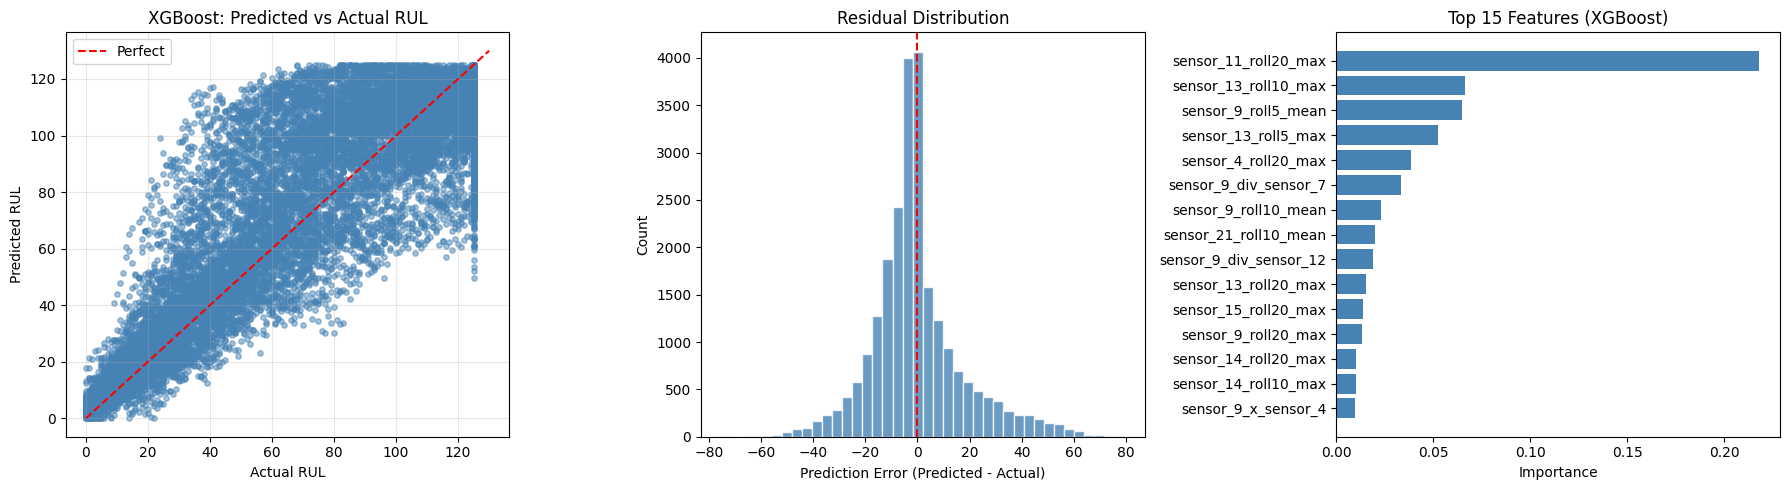

[XGBOOST] Model saved to D:\Capstone Project\models\saved\xgboost_model.pkl


In [10]:
# Visualize XGBoost results
y_pred_rul = xgb_model.predict(X_test_xgb)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted vs Actual
axes[0].scatter(y_test_xgb, y_pred_rul, alpha=0.5, s=15, c="steelblue")
lims = [0, max(y_test_xgb.max(), y_pred_rul.max()) + 5]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect")
axes[0].set_xlabel("Actual RUL")
axes[0].set_ylabel("Predicted RUL")
axes[0].set_title("XGBoost: Predicted vs Actual RUL")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_pred_rul - y_test_xgb.values
axes[1].hist(residuals, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Prediction Error (Predicted - Actual)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

# Feature importance (top 15)
if xgb_model.feature_importance is not None:
    fi = xgb_model.feature_importance.head(15)
    axes[2].barh(fi["feature"], fi["importance"], color="steelblue")
    axes[2].set_xlabel("Importance")
    axes[2].set_title("Top 15 Features (XGBoost)")
    axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

xgb_model.save(os.path.join(config.MODELS_DIR, "xgboost_model.pkl"))

---
## 7. Model 4: Bayesian Weibull Survival Analysis

Weibull Accelerated Failure Time (AFT) model for time-to-failure prediction with
uncertainty quantification. Uses active C-MAPSS sensors plus cycle count as covariates.

In [11]:
# Prepare survival data using C-MAPSS active sensors + cycle
survival_features = config.ACTIVE_SENSORS + ["cycle"]
survival_cols = [c for c in survival_features if c in df_raw.columns] + ["RUL"]

df_survival_train = df_raw[df_raw["unit_id"].isin(train_units)][["unit_id"] + survival_cols].copy()
df_survival_test = df_raw[df_raw["unit_id"].isin(test_units)][["unit_id"] + survival_cols].copy()

survival_model = BayesianSurvival()

try:
    survival_model.fit(df_survival_train)
    survival_model.save(os.path.join(config.MODELS_DIR, "survival_model.pkl"))

    # Evaluate on test
    eval_results = survival_model.evaluate(df_survival_test)
    print(f"\nConcordance Index: {eval_results.get('concordance_index', 'N/A')}")

    # Predict with uncertainty
    predictions = survival_model.predict_with_uncertainty(df_survival_test)
    if predictions is not None:
        print(f"\nSample predictions (first 5):")
        print(predictions.head())

except Exception as e:
    print(f"Survival model fitting failed: {e}")
    print("Skipping — survival analysis may need more data points.")

[SURVIVAL] Preparing survival data...
[SURVIVAL] Fitting Weibull AFT model with 14 covariates, 111227 observations
[SURVIVAL] Event rate: 0.45%
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.022751091253869274
            Iterations: 145
            Function evaluations: 169
            Gradient evaluations: 145
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.022751091253869274
           x: [-4.417e+01  3.131e+00 ...  3.136e+01 -6.645e-01]
         nit: 145
         jac: [ 1.900e-06  2.578e-06 ... -5.219e-07  4.611e-07]
        nfev: 169
        njev: 145
 multipliers: []

[SURVIVAL] Model Summary:


<lifelines.WeibullAFTFitter: fitted with 111227 total observations, 110731 right-censored observations>
             duration col = 'duration'
                event col = 'event'
   number of observations = 111227
number of events observed = 496
           log-likelihood = -2530.536
         time fit was run = 2026-04-10 22:06:47 UTC

---
                     coef exp(coef)       p
param   covariate                          
lambda_ sensor_11 -12.881     0.000 <0.0005
        sensor_12   0.019     1.019   0.917
        sensor_13   0.244     1.276   0.143
        sensor_14   0.013     1.013   0.459
        sensor_15   6.583   722.405 <0.0005
        sensor_17  -1.002     0.367 <0.0005
        sensor_2    0.263     1.301   0.411
        sensor_20   2.739    15.475 <0.0005
        sensor_21   4.703   110.299 <0.0005
        sensor_3   -0.192     0.826 <0.0005
        sensor_4   -0.114     0.892 <0.0005
        sensor_7    0.019     1.019   0.910
        sensor_8    0.210     1.233   0.285
        sensor_9   -0.021     0.980   0.209
        Intercept  31.364 4.182e+13   0.774
rho_    Intercept  -0.664     0.515 <0.0005
---
Concordance = 0.960
AIC = 5093.071
log-likelihood ratio test = 3749.245 on 14 df
-log2(p) of ll-ratio test = inf

[SURVIVAL] Model saved to D:\Capstone Project\models\saved\survival_model.pkl

[SURVIVAL] Evaluation Results:
  C-Index: 0.9507
  RMSE (failures only): 1660583820533.29
  Events: 107 | Censored: 24064

Concordance Index: 0.9506708745525949

Sample predictions (first 5):
Survival model fitting failed: 'dict' object has no attribute 'head'
Skipping — survival analysis may need more data points.


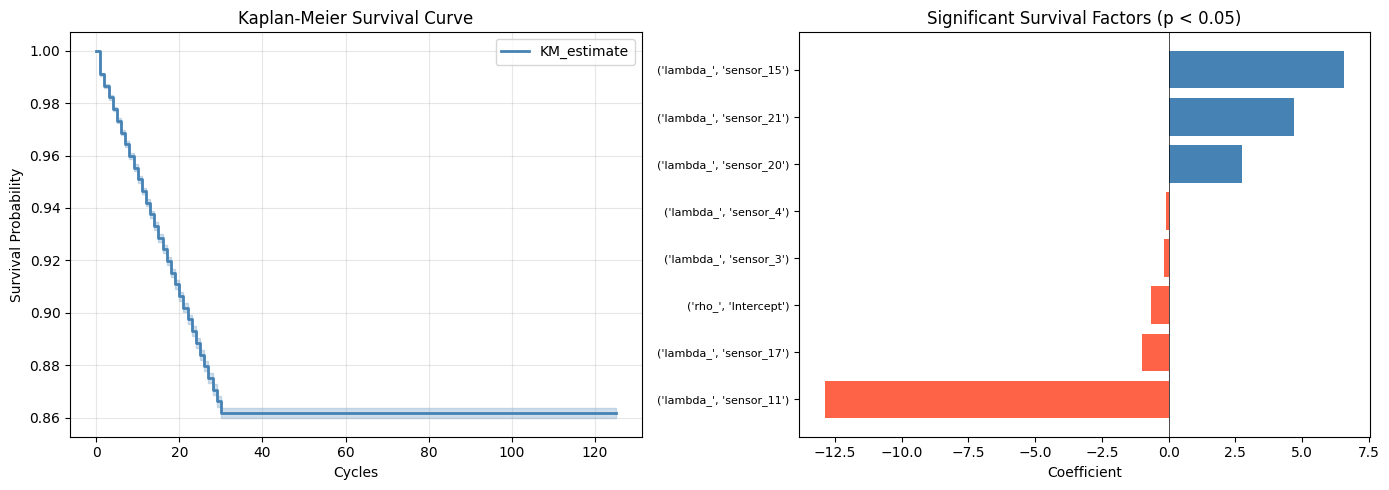

In [12]:
# Visualize Survival Analysis
from lifelines import KaplanMeierFitter

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prepare KM data
df_surv_viz = df_survival_train.copy()
df_surv_viz["duration"] = df_surv_viz["RUL"].clip(lower=1)
df_surv_viz["event"] = (df_surv_viz["RUL"] <= config.PRED_FAILURE_HORIZON).astype(int)

# 1. Kaplan-Meier survival curve
km = KaplanMeierFitter()
km.fit(df_surv_viz["duration"], df_surv_viz["event"])
km.plot_survival_function(ax=axes[0], color="steelblue", linewidth=2)
axes[0].set_xlabel("Cycles"); axes[0].set_ylabel("Survival Probability")
axes[0].set_title("Kaplan-Meier Survival Curve"); axes[0].grid(True, alpha=0.3)

# 2. Weibull AFT coefficient significance
try:
    if survival_model.fitted:
        summary = survival_model.model.summary
        sig_features = summary[summary["p"] < 0.05].sort_values("coef")
        if len(sig_features) > 0:
            colors = ["tomato" if c < 0 else "steelblue" for c in sig_features["coef"]]
            axes[1].barh(range(len(sig_features)), sig_features["coef"], color=colors)
            axes[1].set_yticks(range(len(sig_features)))
            labels = [str(idx) for idx in sig_features.index]
            axes[1].set_yticklabels(labels, fontsize=8)
            axes[1].set_xlabel("Coefficient")
            axes[1].set_title("Significant Survival Factors (p < 0.05)")
            axes[1].axvline(0, color="black", linestyle="-", linewidth=0.5)
        else:
            axes[1].text(0.5, 0.5, "No significant features (p < 0.05)",
                         ha="center", va="center", transform=axes[1].transAxes)
except Exception as e:
    axes[1].text(0.5, 0.5, f"Could not plot coefficients: {e}",
                 ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

---
## 8. Inference Pipeline

Combine all four models into a unified inference pass: anomaly detection,
failure probability, RUL estimate, and survival prediction.

In [13]:
print("=" * 60)
print("INFERENCE PIPELINE — Test Set")
print("=" * 60)

# 1. Anomaly detection
anomaly_scores_all = autoencoder.compute_anomaly_score(torch.tensor(X_test, dtype=torch.float32))
_, is_anomaly = autoencoder.detect_anomalies(torch.tensor(X_test, dtype=torch.float32))

# 2. Failure probability
failure_proba, _ = predictor.predict_proba(torch.tensor(X_test, dtype=torch.float32))

# 3. XGBoost RUL
rul_pred = xgb_model.predict(X_test_xgb)

# Build results table
n_results = min(len(anomaly_scores_all), len(failure_proba), len(rul_pred))
results_df = pd.DataFrame({
    "anomaly_score": anomaly_scores_all[:n_results],
    "is_anomaly": is_anomaly[:n_results],
    "failure_prob": failure_proba[:n_results],
    "predicted_rul": rul_pred[:n_results],
    "actual_rul": y_test_rul[:n_results],
})

# Assign risk levels
def assign_risk(row):
    if row["failure_prob"] >= 0.7 or row["is_anomaly"]:
        return "CRITICAL"
    elif row["failure_prob"] >= 0.4:
        return "ELEVATED"
    return "NORMAL"

results_df["risk_level"] = results_df.apply(assign_risk, axis=1)

print(f"\nRisk Distribution:")
print(results_df["risk_level"].value_counts())
print(f"\nSample Predictions (first 10):")
print(results_df.head(10).to_string(index=False))

INFERENCE PIPELINE — Test Set

Risk Distribution:
risk_level
NORMAL      16863
CRITICAL     3833
ELEVATED      372
Name: count, dtype: int64

Sample Predictions (first 10):
 anomaly_score  is_anomaly  failure_prob  predicted_rul  actual_rul risk_level
      0.000148       False  5.255816e-09     124.570076       125.0     NORMAL
      0.000146       False  3.691712e-09     125.000000       125.0     NORMAL
      0.000151       False  3.558726e-09     125.000000       125.0     NORMAL
      0.000152       False  3.699784e-09     125.000000       125.0     NORMAL
      0.000153       False  3.797302e-09     125.000000       125.0     NORMAL
      0.000154       False  5.299514e-09     125.000000       125.0     NORMAL
      0.000151       False  7.642122e-09     125.000000       125.0     NORMAL
      0.000152       False  1.324145e-08     124.457405       125.0     NORMAL
      0.000154       False  2.156268e-08     124.039177       125.0     NORMAL
      0.000151       False  2.839891e

---
## 9. MILP Maintenance Scheduling

Formulates a Mixed-Integer Linear Program to optimally schedule maintenance jobs
given predicted failure risks, crew constraints, and cost parameters.

In [14]:
# Use actual test unit IDs and their latest failure probability
# Matches run_pipeline.py exactly — no random sampling
unit_risks = {}
for uid in np.unique(unit_ids_test):
    mask = unit_ids_test == uid
    latest_idx = np.where(mask)[0][-1]
    unit_risks[int(uid)] = float(failure_proba[latest_idx])

machine_names = {uid: f"Engine-{uid:03d}" for uid in unit_risks}

scheduler = MaintenanceScheduler()
schedule_result = scheduler.create_schedule(
    machine_risks=unit_risks,
    machine_names=machine_names,
)

print(f"Optimization Status: {schedule_result['status']}")
print(f"Engines assessed: {len(unit_risks)}")
print(f"Total Estimated Cost: ${schedule_result['total_cost']:,.2f}")

schedule = schedule_result['schedule']

# Build recommendations — same schema as run_pipeline.py
recommendations = []
for _, row in schedule.iterrows():
    uid = row['machine_id']
    uid_mask = unit_ids_test == uid
    is_anom = bool(
        anomaly_scores[np.where(uid_mask)[0][-1]] > autoencoder.threshold
    ) if uid_mask.any() else False
    recommendations.append({
        'machine': row['machine_name'],
        'risk_score': row['failure_risk'],
        'risk_level': row['risk_level'],
        'action': (
            'Immediate maintenance' if row['risk_level'] == 'Service Immediately'
            else 'Schedule maintenance' if row['risk_level'] == 'Schedule Soon'
            else 'Continue monitoring'
        ),
        'scheduled_slot': row['scheduled_slot'] if row['is_scheduled'] else 'N/A',
        'is_anomalous': is_anom,
    })

rec_df = pd.DataFrame(recommendations)
rec_df.to_csv(
    os.path.join(config.PROCESSED_DATA_DIR, 'recommendations.csv'), index=False)
print(f'Recommendations saved: {len(rec_df)} engines')
print(rec_df[['machine','risk_score','risk_level','scheduled_slot']].head(10).to_string(index=False))



[MILP] Scheduling 107 machines across 10 time slots
[MILP] Max crews: 3
[MILP] Solution status: Infeasible
[MILP] Total expected cost: $inf

OPTIMIZED MAINTENANCE SCHEDULE

[!!] SERVICE IMMEDIATELY:
   Engine-002           | Risk: 100.00% | Slot 2.0
   Engine-014           | Risk: 100.00% | UNSCHEDULED!
   Engine-015           | Risk: 100.00% | UNSCHEDULED!
   Engine-021           | Risk: 100.00% | UNSCHEDULED!
   Engine-022           | Risk: 100.00% | UNSCHEDULED!
   Engine-028           | Risk: 100.00% | UNSCHEDULED!
   Engine-041           | Risk: 100.00% | Slot 4.0
   Engine-059           | Risk: 100.00% | UNSCHEDULED!
   Engine-053           | Risk: 100.00% | Slot 4.0
   Engine-063           | Risk: 100.00% | Slot 2.0
   Engine-065           | Risk: 100.00% | UNSCHEDULED!
   Engine-252           | Risk: 100.00% | UNSCHEDULED!
   Engine-072           | Risk: 100.00% | UNSCHEDULED!
   Engine-081           | Risk: 100.00% | UNSCHEDULED!
   Engine-088           | Risk: 100.00% | UNSC

---
## 10. Monte Carlo Simulation — Policy Comparison

Simulates three maintenance policies over many runs to compare:
1. **Reactive** — fix after failure
2. **Scheduled** — fixed-interval preventive maintenance
3. **Optimized** — risk-based scheduling (our approach)

In [15]:
simulator = MaintenanceSimulator(n_machines=50, n_periods=100)
sim_df, sim_summary = simulator.run_comparison(n_simulations=100)

print("\nSimulation Summary:")
for policy, metrics in sim_summary.items():
    print(f"\n  {policy}:")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"    {k}: {v:,.2f}")
        else:
            print(f"    {k}: {v}")

Monte Carlo Simulation (100 runs)
  Machines: 50 | Periods: 100
  Completed 20/100 simulations
  Completed 40/100 simulations
  Completed 60/100 simulations
  Completed 80/100 simulations
  Completed 100/100 simulations

----------------------------------------------------------------------
SIMULATION RESULTS (averaged over simulations)
----------------------------------------------------------------------
                       total_cost            total_downtime_hours        availability_pct n_failures n_preventive
                             mean        std                 mean    std             mean       mean         mean
policy                                                                                                           
Optimized (Risk-Based)   181464.0   97370.42               204.68   7.41            99.83       0.39        49.61
Reactive                7446400.0  311333.14               744.64  31.13            99.38      46.54         0.00
Scheduled (every 30)

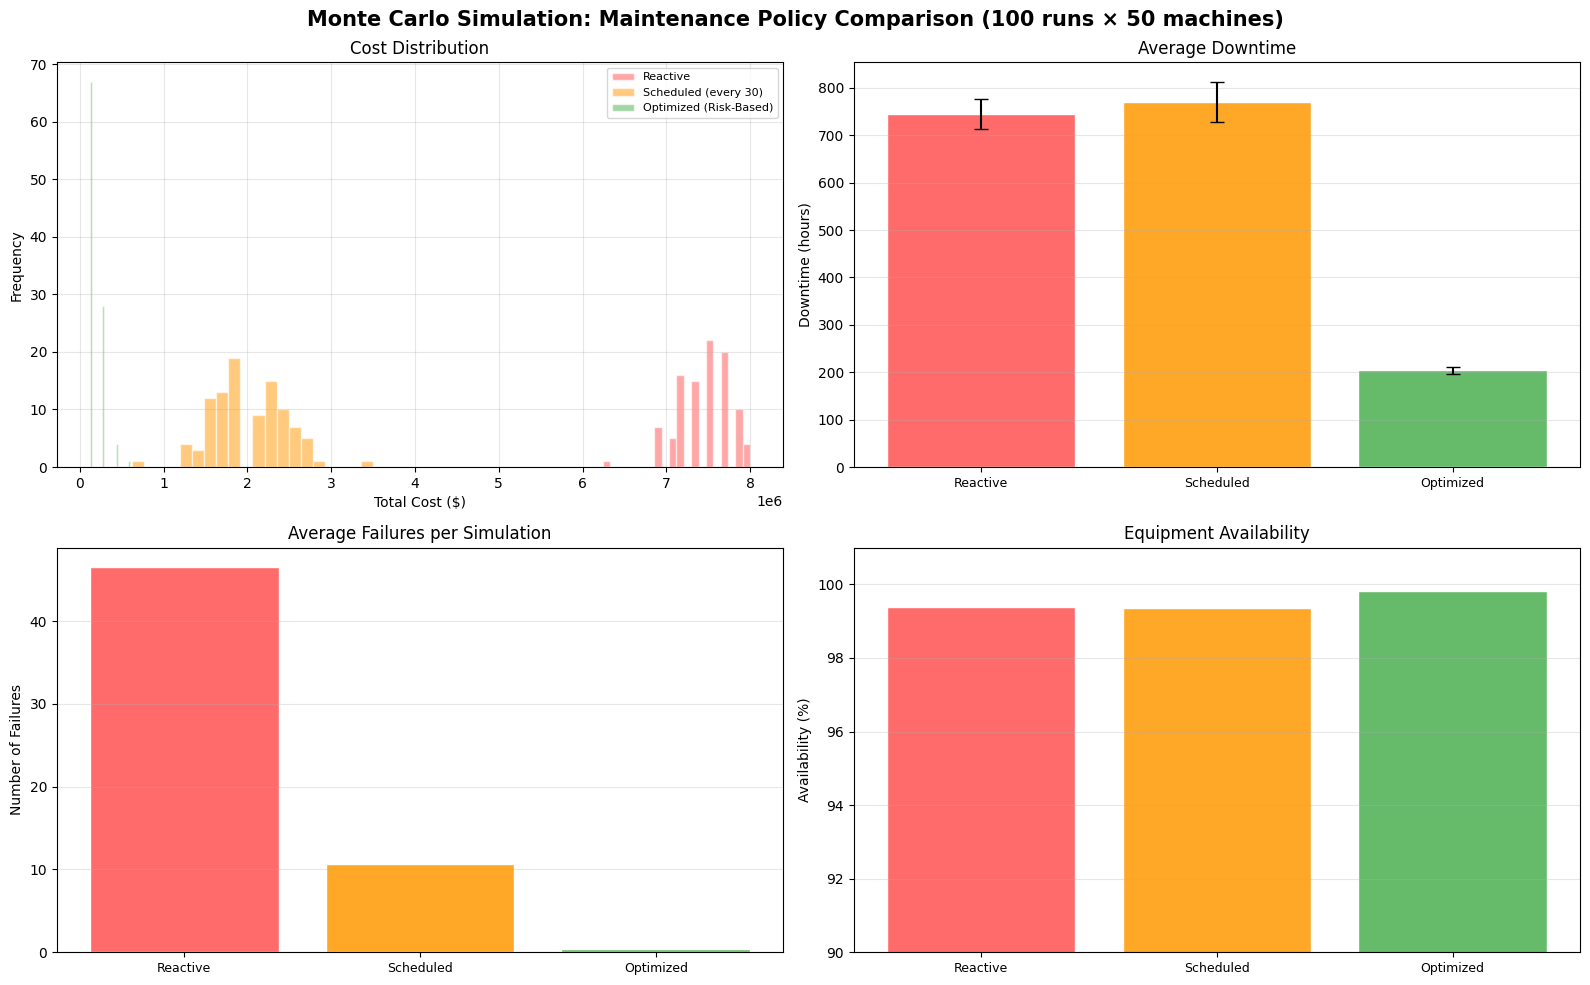

In [16]:
# Visualize simulation results
policy_colors = {"Reactive": "#FF6B6B", "Scheduled (every 30)": "#FFA726",
                 "Optimized (Risk-Based)": "#66BB6A"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Monte Carlo Simulation: Maintenance Policy Comparison (100 runs × 50 machines)",
             fontsize=15, fontweight="bold")

# 1. Cost distribution (overlapping histograms)
ax = axes[0, 0]
for policy, color in policy_colors.items():
    data = sim_df[sim_df["policy"] == policy]["total_cost"]
    ax.hist(data, bins=20, alpha=0.6, label=policy, color=color, edgecolor="white")
ax.set_xlabel("Total Cost ($)"); ax.set_ylabel("Frequency")
ax.set_title("Cost Distribution"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 2. Downtime comparison (bar + error bars)
ax = axes[0, 1]
policies = list(policy_colors.keys())
means = [sim_df[sim_df["policy"] == p]["total_downtime_hours"].mean() for p in policies]
stds = [sim_df[sim_df["policy"] == p]["total_downtime_hours"].std() for p in policies]
bars = ax.bar(range(len(policies)), means, yerr=stds,
              color=[policy_colors[p] for p in policies], capsize=5, edgecolor="white")
ax.set_xticks(range(len(policies)))
ax.set_xticklabels(["Reactive", "Scheduled", "Optimized"], fontsize=9)
ax.set_ylabel("Downtime (hours)"); ax.set_title("Average Downtime")
ax.grid(True, alpha=0.3, axis="y")

# 3. Failures comparison
ax = axes[1, 0]
means = [sim_df[sim_df["policy"] == p]["n_failures"].mean() for p in policies]
bars = ax.bar(range(len(policies)), means,
              color=[policy_colors[p] for p in policies], edgecolor="white")
ax.set_xticks(range(len(policies)))
ax.set_xticklabels(["Reactive", "Scheduled", "Optimized"], fontsize=9)
ax.set_ylabel("Number of Failures"); ax.set_title("Average Failures per Simulation")
ax.grid(True, alpha=0.3, axis="y")

# 4. Availability comparison
ax = axes[1, 1]
means = [sim_df[sim_df["policy"] == p]["availability_pct"].mean() for p in policies]
bars = ax.bar(range(len(policies)), means,
              color=[policy_colors[p] for p in policies], edgecolor="white")
ax.set_xticks(range(len(policies)))
ax.set_xticklabels(["Reactive", "Scheduled", "Optimized"], fontsize=9)
ax.set_ylabel("Availability (%)"); ax.set_title("Equipment Availability")
ax.set_ylim(90, 101)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

---
## 11. Explainability

### 11a. SHAP Feature Attribution (XGBoost)
Shows which features drive the RUL predictions.

In [17]:
shap_explainer = SHAPExplainer(xgb_model, model_type="xgboost")
shap_explainer.setup_explainer()
shap_values = shap_explainer.compute_shap_values(X_test_xgb)

# Sensor ranking
sensor_ranking = shap_explainer.get_sensor_ranking()

[SHAP] TreeExplainer initialized for XGBoost
[SHAP] Computing SHAP values for 500 samples...
[SHAP] SHAP values computed successfully

[SHAP] Sensor Ranking (Top 15):
             feature  mean_abs_shap
sensor_11_roll20_max      10.328343
sensor_13_roll10_max       4.164910
 sensor_4_roll20_max       4.082366
 sensor_13_roll5_max       2.360446
 sensor_9_roll20_max       1.895774
sensor_15_roll20_max       1.740129
sensor_14_roll20_max       1.652788
sensor_13_roll20_max       0.973560
sensor_12_roll10_max       0.966382
sensor_14_roll10_max       0.896091
 sensor_8_roll20_max       0.878358
sensor_11_roll10_min       0.801150
sensor_15_roll20_min       0.796601
sensor_21_roll20_max       0.786505
 sensor_2_roll10_max       0.786101


C:\Users\devas\AppData\Local\Temp\ipykernel_17012\1075911660.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_explainer.X_sample,
C:\Users\devas\AppData\Local\Temp\ipykernel_17012\1075911660.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_explainer.X_sample,


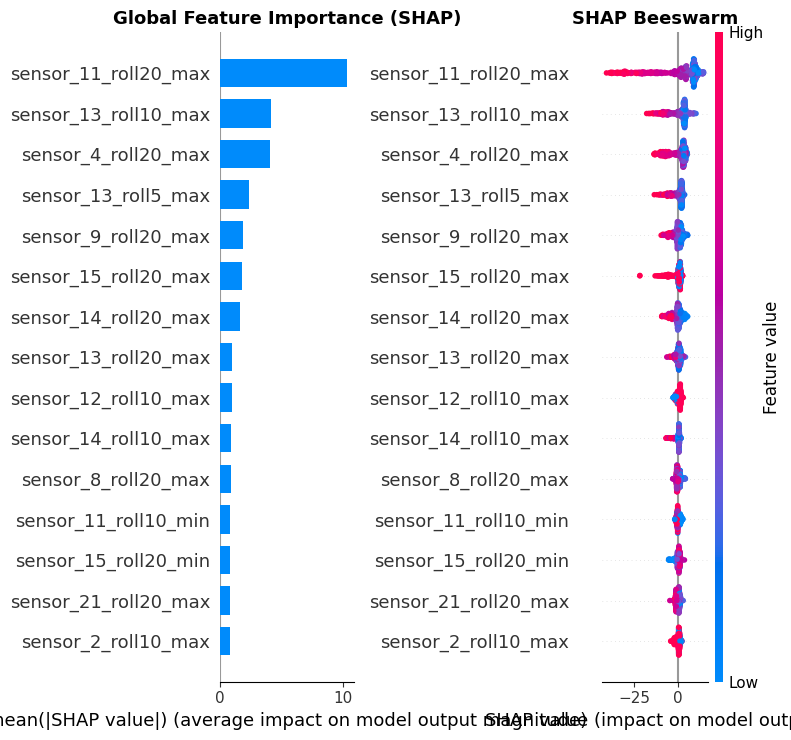

In [18]:
# SHAP plots (inline)
import shap

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_values, shap_explainer.X_sample,
                  feature_names=shap_explainer.feature_names,
                  plot_type="bar", max_display=15, show=False)
axes[0].set_title("Global Feature Importance (SHAP)", fontsize=13, fontweight="bold")

plt.sca(axes[1])
shap.summary_plot(shap_values, shap_explainer.X_sample,
                  feature_names=shap_explainer.feature_names,
                  max_display=15, show=False)
axes[1].set_title("SHAP Beeswarm", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

### 11b. Attention Visualization (LSTM Predictor)

Shows which time steps the LSTM predictor attends to when making failure predictions.

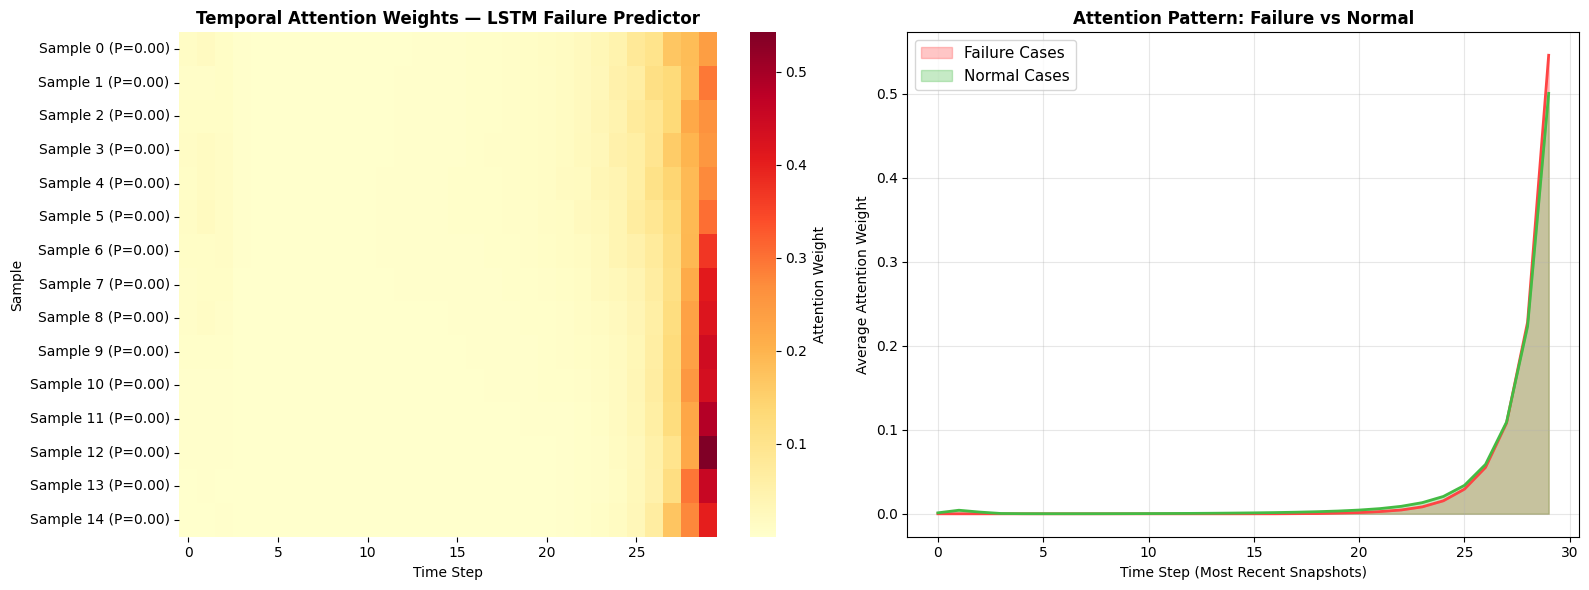

In [19]:
attn_viz = AttentionVisualizer(predictor)

# Extract attention weights
attn_weights, attn_preds = attn_viz.extract_attention(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Attention heatmap for top samples
n_show = min(15, len(attn_weights))
import seaborn as sns
sns.heatmap(attn_weights[:n_show], cmap="YlOrRd", ax=axes[0],
            xticklabels=5,
            yticklabels=[f"Sample {i} (P={attn_preds[i]:.2f})" for i in range(n_show)],
            cbar_kws={"label": "Attention Weight"})
axes[0].set_xlabel("Time Step"); axes[0].set_ylabel("Sample")
axes[0].set_title("Temporal Attention Weights — LSTM Failure Predictor", fontsize=12, fontweight="bold")

# 2. Average attention: failure vs normal
fail_mask = y_test_binary == 1
normal_mask = y_test_binary == 0
avg_fail = attn_weights[fail_mask].mean(axis=0) if fail_mask.sum() > 0 else np.zeros(attn_weights.shape[1])
avg_normal = attn_weights[normal_mask].mean(axis=0) if normal_mask.sum() > 0 else np.zeros(attn_weights.shape[1])

x_axis = np.arange(len(avg_fail))
axes[1].fill_between(x_axis, avg_fail, alpha=0.3, color="#FF4444", label="Failure Cases")
axes[1].fill_between(x_axis, avg_normal, alpha=0.3, color="#44BB44", label="Normal Cases")
axes[1].plot(x_axis, avg_fail, color="#FF4444", linewidth=2)
axes[1].plot(x_axis, avg_normal, color="#44BB44", linewidth=2)
axes[1].set_xlabel("Time Step (Most Recent Snapshots)")
axes[1].set_ylabel("Average Attention Weight")
axes[1].set_title("Attention Pattern: Failure vs Normal", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 12. Overfitting Diagnostic

Compare train vs test metrics to check for data leakage or overfitting.

In [20]:
from sklearn.metrics import mean_absolute_error, r2_score

print("=" * 60)
print("OVERFITTING DIAGNOSTIC")
print("=" * 60)

# LSTM Predictor: train vs test
y_proba_train, _ = predictor.predict_proba(torch.tensor(X_train, dtype=torch.float32))
y_pred_train = (y_proba_train >= 0.5).astype(int)
f1_train = f1_score(y_train_binary.astype(int), y_pred_train, zero_division=0)

y_proba_test, _ = predictor.predict_proba(torch.tensor(X_test, dtype=torch.float32))
y_pred_test = (y_proba_test >= 0.5).astype(int)
f1_test = f1_score(y_test_binary.astype(int), y_pred_test, zero_division=0)

print(f"\nLSTM Predictor:")
print(f"  Train F1: {f1_train:.4f}")
print(f"  Test  F1: {f1_test:.4f}")
print(f"  Gap:      {abs(f1_train - f1_test):.4f} {'(OK)' if abs(f1_train - f1_test) < 0.15 else '(POSSIBLE OVERFIT)'}")

# XGBoost: train vs test
y_rul_train_pred = xgb_model.predict(X_train_xgb)
y_rul_test_pred = xgb_model.predict(X_test_xgb)

mae_train = mean_absolute_error(y_train_xgb, y_rul_train_pred)
mae_test = mean_absolute_error(y_test_xgb, y_rul_test_pred)
r2_train = r2_score(y_train_xgb, y_rul_train_pred)
r2_test = r2_score(y_test_xgb, y_rul_test_pred)

print(f"\nXGBoost RUL:")
print(f"  Train MAE: {mae_train:.2f}  |  Test MAE: {mae_test:.2f}")
print(f"  Train R2:  {r2_train:.4f}  |  Test R2:  {r2_test:.4f}")
print(f"  MAE Gap:   {abs(mae_train - mae_test):.2f} {'(OK)' if abs(mae_train - mae_test) < 10 else '(POSSIBLE OVERFIT)'}")

# Autoencoder: healthy vs degraded
scores_healthy = autoencoder.compute_anomaly_score(torch.tensor(X_healthy[:100], dtype=torch.float32))
scores_test = autoencoder.compute_anomaly_score(torch.tensor(X_test, dtype=torch.float32))
print(f"\nAutoencoder Anomaly Scores:")
print(f"  Healthy mean: {scores_healthy.mean():.6f} +/- {scores_healthy.std():.6f}")
print(f"  Test mean:    {scores_test.mean():.6f} +/- {scores_test.std():.6f}")
print(f"  Separation:   {'GOOD' if scores_test.mean() > scores_healthy.mean() * 1.5 else 'WEAK'}")

OVERFITTING DIAGNOSTIC

LSTM Predictor:
  Train F1: 0.8362
  Test  F1: 0.8615
  Gap:      0.0253 (OK)

XGBoost RUL:
  Train MAE: 7.69  |  Test MAE: 12.43
  Train R2:  0.9315  |  Test R2:  0.8134
  MAE Gap:   4.74 (OK)

Autoencoder Anomaly Scores:
  Healthy mean: 0.000104 +/- 0.000003
  Test mean:    0.008112 +/- 0.007082
  Separation:   GOOD


---
## 13. Summary Dashboard

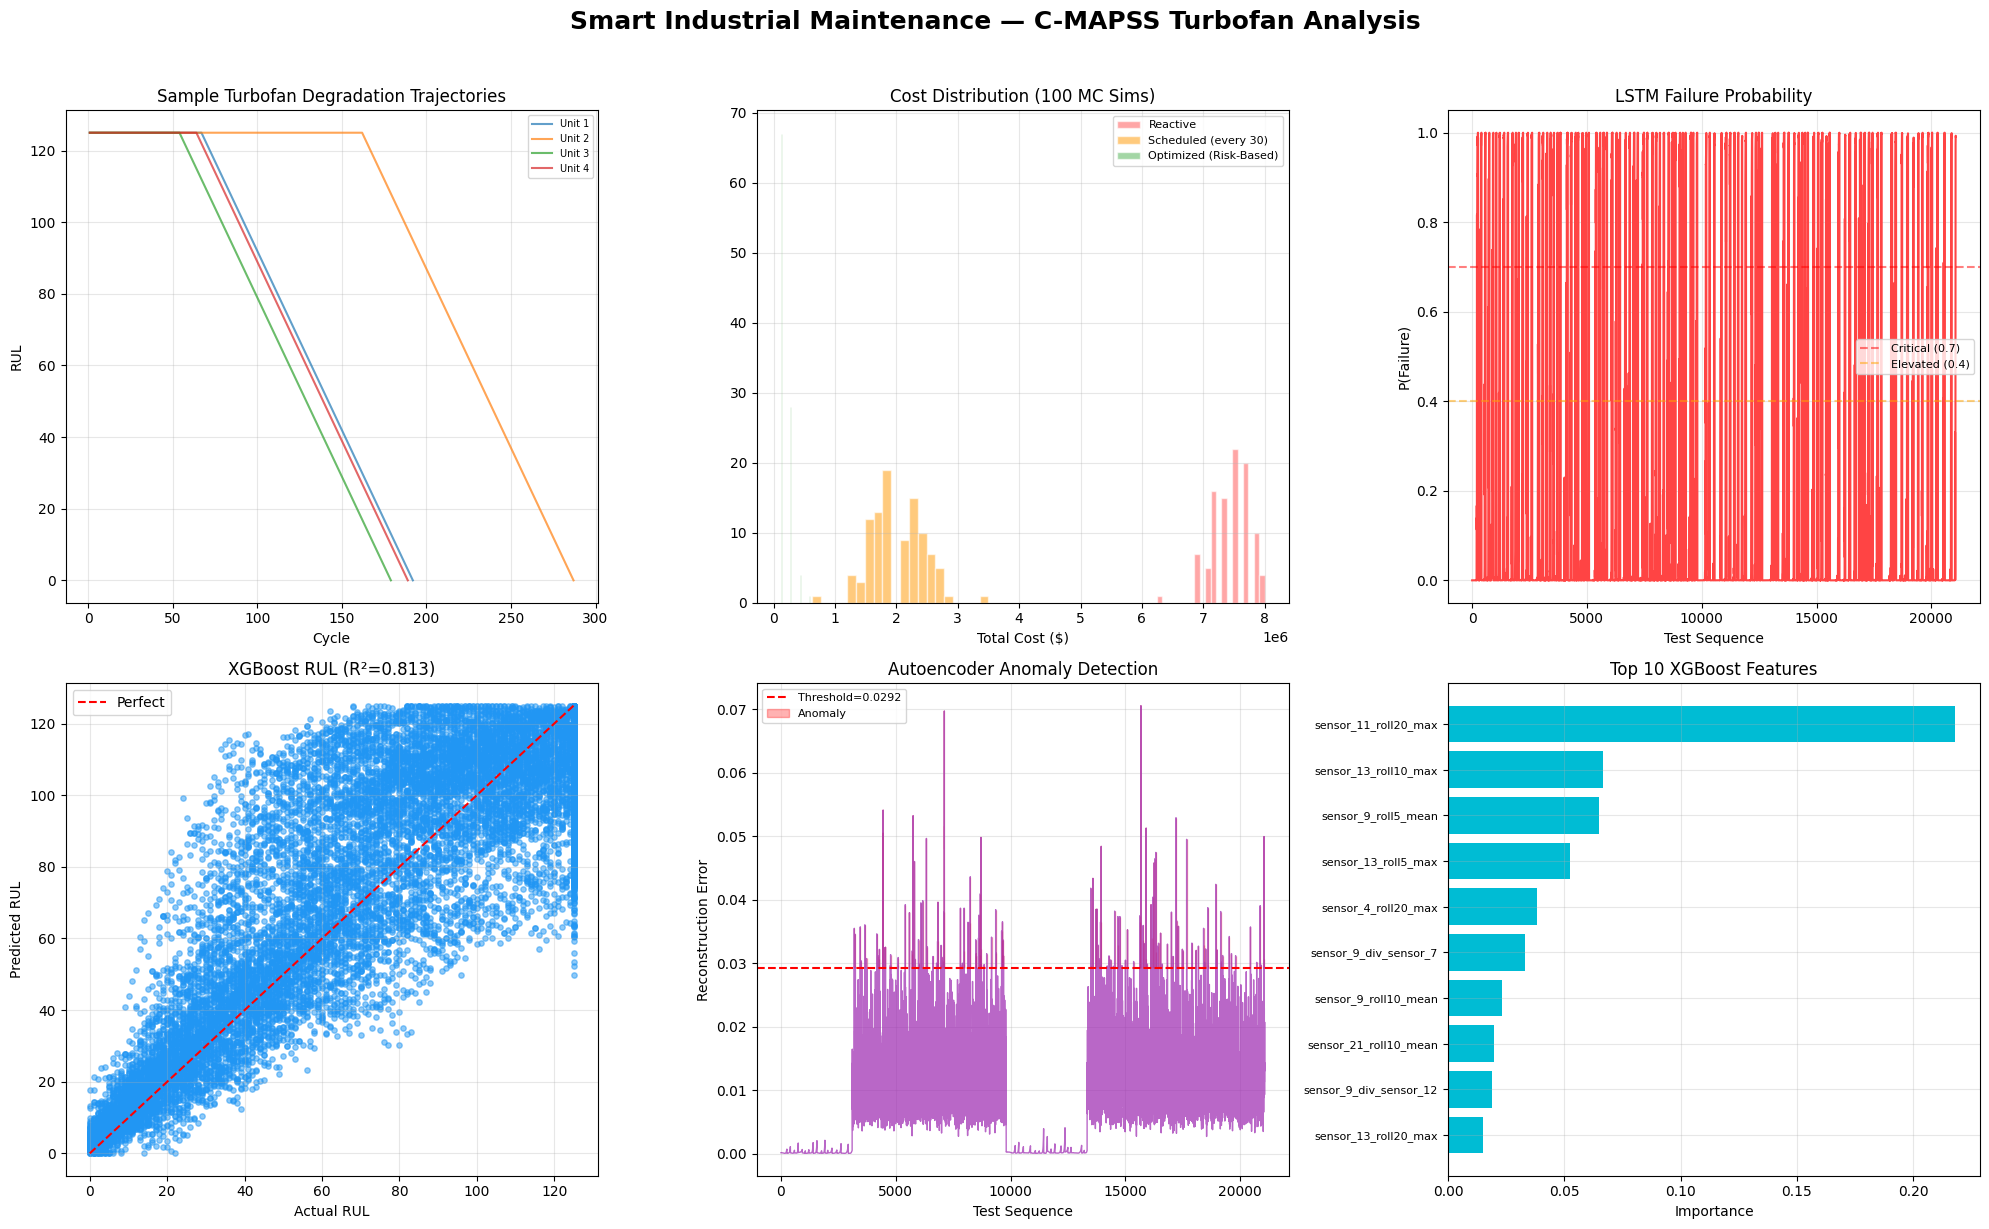

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Smart Industrial Maintenance — C-MAPSS Turbofan Analysis",
             fontsize=18, fontweight="bold", y=1.02)

policy_colors = {"Reactive": "#FF6B6B", "Scheduled (every 30)": "#FFA726",
                 "Optimized (Risk-Based)": "#66BB6A"}

# 1. Sample Degradation Trajectories
ax = axes[0, 0]
for uid in sorted(df_raw["unit_id"].unique())[:4]:
    unit_df = df_raw[df_raw["unit_id"] == uid].sort_values("cycle")
    ax.plot(unit_df["cycle"], unit_df["RUL"], alpha=0.7, label=f"Unit {uid}")
ax.set_xlabel("Cycle"); ax.set_ylabel("RUL")
ax.set_title("Sample Turbofan Degradation Trajectories")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# 2. Monte Carlo Cost Distribution
ax = axes[0, 1]
for pol, color in policy_colors.items():
    ax.hist(sim_df[sim_df["policy"] == pol]["total_cost"], alpha=0.6,
            label=pol, color=color, bins=20, edgecolor="white")
ax.set_xlabel("Total Cost ($)"); ax.set_title("Cost Distribution (100 MC Sims)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 3. Failure Probability Timeline
ax = axes[0, 2]
ax.plot(failure_proba, color="#FF4444", linewidth=1.5)
ax.axhline(y=0.7, color="red", linestyle="--", alpha=0.5, label="Critical (0.7)")
ax.axhline(y=0.4, color="orange", linestyle="--", alpha=0.5, label="Elevated (0.4)")
ax.set_xlabel("Test Sequence"); ax.set_ylabel("P(Failure)")
ax.set_title("LSTM Failure Probability"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 4. XGBoost RUL: Predicted vs Actual
ax = axes[1, 0]
ax.scatter(y_test_xgb, rul_pred, alpha=0.5, s=15, color="#2196F3")
ax.plot([0, y_test_xgb.max()], [0, y_test_xgb.max()], "r--", label="Perfect")
ax.set_xlabel("Actual RUL"); ax.set_ylabel("Predicted RUL")
ax.set_title(f"XGBoost RUL (R²={r2_test:.3f})"); ax.legend(); ax.grid(True, alpha=0.3)

# 5. Anomaly Detection Timeline
ax = axes[1, 1]
ax.plot(anomaly_scores_all, color="#9C27B0", alpha=0.7, linewidth=1)
ax.axhline(y=autoencoder.threshold, color="red", linestyle="--",
           label=f"Threshold={autoencoder.threshold:.4f}")
ax.fill_between(range(len(anomaly_scores_all)), anomaly_scores_all, autoencoder.threshold,
                where=anomaly_scores_all > autoencoder.threshold,
                alpha=0.3, color="red", label="Anomaly")
ax.set_xlabel("Test Sequence"); ax.set_ylabel("Reconstruction Error")
ax.set_title("Autoencoder Anomaly Detection"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 6. Top 10 Feature Importance
ax = axes[1, 2]
if xgb_model.feature_importance is not None:
    top10 = xgb_model.feature_importance.head(10)
    ax.barh(range(len(top10)), top10["importance"].values, color="#00BCD4")
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels([name[:28] for name in top10["feature"].values], fontsize=8)
    ax.set_xlabel("Importance"); ax.set_title("Top 10 XGBoost Features")
    ax.invert_yaxis(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 14. Final Metrics Summary

In [22]:
print("=" * 70)
print("  SMART INDUSTRIAL MAINTENANCE — FINAL RESULTS (C-MAPSS Turbofan)")
print("=" * 70)

print(f"\n  Device: {config.DEVICE}")
print(f"  Subsets: {config.CMAPSS_SUBSETS}")
print(f"  Units: {df_raw['unit_id'].nunique()}")
print(f"  Features: {n_features}")
print(f"  Sequence Length: {config.SEQUENCE_LENGTH}")
print(f"  Synthetic Augmentation: {config.SYNTHETIC_AUGMENT} "
      f"(target ratio: {config.SYNTHETIC_TARGET_RATIO:.0%})")

print(f"\n  {'Model':<30} {'Metric':<20} {'Value':>10}")
print(f"  {'-'*60}")
print(f"  {'LSTM Autoencoder':<30} {'Anomaly Rate':<20} {is_anomaly.mean():>10.2%}")
print(f"  {'LSTM Predictor':<30} {'Test F1':<20} {f1_test:>10.4f}")
print(f"  {'LSTM Predictor':<30} {'Test AUC':<20} {roc_auc:>10.4f}")
print(f"  {'XGBoost RUL':<30} {'Test MAE':<20} {mae_test:>10.2f}")
print(f"  {'XGBoost RUL':<30} {'Test R2':<20} {r2_test:>10.4f}")

try:
    if survival_model.fitted:
        eval_results = survival_model.evaluate(df_survival_test)
        c_idx = eval_results.get("concordance_index", "N/A")
        print(f"  {'Survival Model':<30} {'C-Index':<20} {c_idx:>10.4f}" if isinstance(c_idx, float) else f"  {'Survival Model':<30} {'C-Index':<20} {c_idx:>10}")
except Exception:
    pass

if not sim_summary.empty:
    try:
        opt_cost = sim_summary.loc["Optimized (Risk-Based)", ("total_cost", "mean")]
        react_cost = sim_summary.loc["Reactive", ("total_cost", "mean")]
        if react_cost > 0:
            savings = (1 - opt_cost / react_cost) * 100
            print(f"  {'Optimized Policy':<30} {'Cost Savings vs Reactive':<20} {savings:>9.1f}%")
    except KeyError:
        pass

print(f"\n  Saved models:")
for f in sorted(os.listdir(config.MODELS_DIR)):
    if f.endswith((".pt", ".pkl")):
        size = os.path.getsize(os.path.join(config.MODELS_DIR, f)) / 1e6
        print(f"    {f} ({size:.2f} MB)")

print(f"\n{'='*70}")
print("  Pipeline complete. Run 'streamlit run dashboard/app.py' for the dashboard.")
print(f"{'='*70}")

  SMART INDUSTRIAL MAINTENANCE — FINAL RESULTS (C-MAPSS Turbofan)

  Device: cuda
  Subsets: ['FD001', 'FD002', 'FD003', 'FD004']
  Units: 709
  Features: 16
  Sequence Length: 30
  Synthetic Augmentation: True (target ratio: 30%)

  Model                          Metric                    Value
  ------------------------------------------------------------
  LSTM Autoencoder               Anomaly Rate              0.97%
  LSTM Predictor                 Test F1                  0.8615
  LSTM Predictor                 Test AUC                 0.9898
  XGBoost RUL                    Test MAE                  12.43
  XGBoost RUL                    Test R2                  0.8134

[SURVIVAL] Evaluation Results:
  C-Index: 0.9507
  RMSE (failures only): 1660583820533.29
  Events: 107 | Censored: 24064
  Survival Model                 C-Index                  0.9507
  Optimized Policy               Cost Savings vs Reactive      97.6%

  Saved models:
    autoencoder.pt (0.51 MB)
    bayesian

---
## 15. Auto-Update Dashboard Screenshots

Captures fresh screenshots of all 7 dashboard pages and saves them to `assets/`.
Requires `playwright` — silently skipped if not installed
(`pip install playwright && playwright install chromium`).

In [23]:
try:
    import sys as _sys
    import os as _os
    _sys.path.insert(0, _os.path.join(config.PROJECT_ROOT, 'scripts'))
    from capture_screenshots import capture
    capture()
except Exception as _e:
    print(f"Screenshot capture skipped: {_e}")
    print("To enable: pip install playwright && playwright install chromium")


[SCREENSHOTS] Starting Streamlit on port 8502 ...
Screenshot capture skipped: It looks like you are using Playwright Sync API inside the asyncio loop.
Please use the Async API instead.
To enable: pip install playwright && playwright install chromium
